In [1]:
# importing libraries  
import numpy as nm  
import matplotlib.pyplot as mtp  
import pandas as pd  
import matplotlib.pyplot as mtp 
from sklearn.compose import ColumnTransformer

/Users/lmiralles/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [2]:
#importing datasets  Y = mX + B
data_set= pd.read_csv('./DataSets/50_CompList.csv')

In [3]:
data_set

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [4]:
#Extracting Independent and dependent Variable  
x= data_set.iloc[:, :-1].values  
y= data_set.iloc[:, 4].values  

In [5]:
#Catgorical data  
from sklearn.preprocessing import LabelEncoder, OneHotEncoder  
labelencoder_x= LabelEncoder()  
x[:, 3]= labelencoder_x.fit_transform(x[:,3])  
ct = ColumnTransformer([('encoder', OneHotEncoder(), [3])], remainder='passthrough')
x = ct.fit_transform(x)

In [6]:
# dublin, galway, cork, limerik   = OneHotEncoder(1,2,3,4) = [0,0], [0,1], [1,0] , [1,1]  

In [7]:
#avoiding the dummy variable trap:  
x = x[:, 1:]  

In [8]:
# Splitting the dataset into training and test set.  
from sklearn.model_selection import train_test_split  
x_train, x_test, y_train, y_test= train_test_split(x, y, test_size= 0.2, random_state=0)

In [9]:
#Fitting the MLR model to the training set:  
from sklearn.linear_model import LinearRegression  
regressor= LinearRegression()  
regressor.fit(x_train, y_train)  

LinearRegression()

In [10]:
#Predicting the Test set result;  
y_pred= regressor.predict(x_test)  

In [11]:
print('Train Score: ', regressor.score(x_train, y_train))  
print('Test Score: ', regressor.score(x_test, y_test))

Train Score:  0.9501847627493607
Test Score:  0.9347068473282434


ValueError: x and y must be the same size

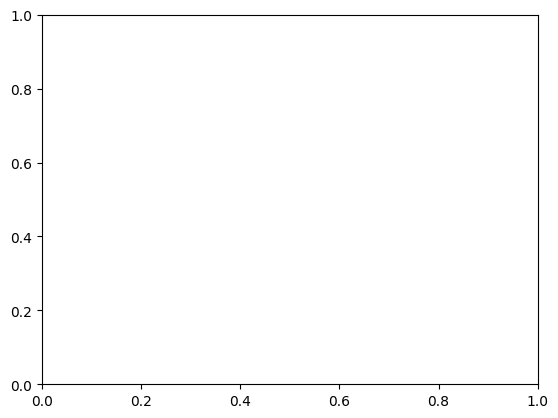

In [12]:
mtp.scatter(x_train, y_train, color="green")   
mtp.plot(x_test,y_test, color="red")    
mtp.title("Salary vs Experience (Training Dataset)")  
mtp.xlabel("Years of Experience")  
mtp.ylabel("Salary(In Rupees)")  
mtp.show()  